In [173]:
import matplotlib.pyplot as plt
import numpy as np

from firm3d.plotting.plotting_helpers import plot_trajectory_poloidal

In [204]:
nParticles = int(10000)
# Critical angle for barely trapped particle classification
barely_trapped_crit = 2 * np.pi * 1.25
# Critical value of dchi/dchi_predicted for ripple trapped
ripple_trapped_crit = 0.5

trapped_bool = []  # True if particle mirrors at least once
barely_trapped_frac = []  # Fraction barely trapped (dchis > 2*pi)
ripple_trapped_frac = []  # Fraction ripple trapped
banana_frac = []  # Fraction banana trapped (in main well)
Jpar_var = []  # Variation in Jpar (nbounce > 3, otherwise 0)
nbounces = []  # Number of mirror points
gammac_mean = []  # Mean Gammac (nbounce > 1, otherwise 0)
indices = []  # Particle indices for those lost to the wall
timelost = []  # Time lost to the wall for particles that were lost
ntransitions = []  # Number of transitions between trapped states
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"data_QA/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    trapped_bool.append(dict["nbounce"] > 0)
    barely_trapped_frac.append(dict["barely_trapped_frac"])
    ripple_trapped_frac.append(dict["ripple_trapped_frac"])
    banana_frac.append(dict["banana_frac"])
    Jpar_var.append(dict["Jpar_var"])
    nbounces.append(dict["nbounce"])
    gammac_mean.append(dict["gammac_mean"])
    indices.append(iParticle)
    timelost.append(dict["losttime"])
    ntransitions.append(dict["ntransitions"])

trapped_bool = np.array(trapped_bool)
barely_trapped_frac = np.array(barely_trapped_frac)
ripple_trapped_frac = np.array(ripple_trapped_frac)
banana_frac = np.array(banana_frac)
Jpar_var = np.array(Jpar_var)
nbounces = np.array(nbounces)
gammac_mean = np.array(gammac_mean)
indices = np.array(indices)
timelost = np.array(timelost)
ntransitions = np.array(ntransitions)

num_trapped = np.count_nonzero(trapped_bool)
num_passing = np.count_nonzero(trapped_bool <= 2)
print(f"Number of trapped particles: {num_trapped}")
print(f"Number of passing/sub-bounce particles: {num_passing}")
print(f"Number of barely trapped particles: {np.count_nonzero(barely_trapped_frac)}")
print(f"Number of ripple trapped particles: {np.count_nonzero(ripple_trapped_frac)}")
print(f"Number of pure banana particles: {np.count_nonzero(banana_frac == 1)}")
num_trdb = np.count_nonzero(Jpar_var>0.01)
print(f"Number of diffusive banana : {num_trdb}")
num_trcb = num_trapped - num_trdb

# need subbounce, num_trapped, num_passing
np.save('plotting/subbounce_QA',num_passing)
np.save('plotting/num_trapped_QA',num_trapped)
np.save('plotting/num_passing_QA',num_passing)
np.save('plotting/num_trdb_QA',num_trdb)
np.save('plotting/num_trcb_QA',num_trcb)

Number of trapped particles: 74
Number of passing particles: 82
Number of barely trapped particles: 8
Number of ripple trapped particles: 8
Number of pure banana particles: 27
Number of sub-bounce : 82
Number of diffusive banana : 33


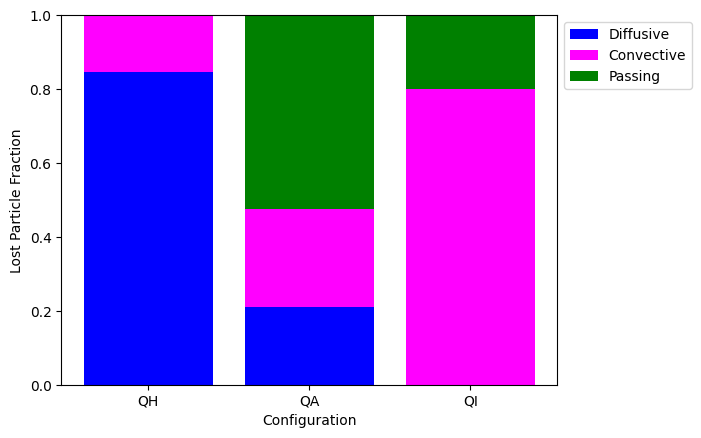

In [205]:
# Stacked Bar Chart
categories = ['QH','QA','QI']
x = np.arange(len(categories))

#QH
subbounce_QH = np.load('plotting/subbounce_QH.npy')
num_trapped_QH = np.load('plotting/num_trapped_QH.npy')
num_passing_QH = np.load('plotting/num_passing_QH.npy')
num_trdb_QH = np.load('plotting/num_trdb_QH.npy')
num_trcb_QH = np.load('plotting/num_trcb_QH.npy')

nQH = num_trapped_QH+num_passing_QH
tr_db_QH = [num_trdb_QH/nQH] # Diffusive banana
tr_cb_QH = [num_trcb_QH/nQH] # Convective banana
sb_QH = [subbounce_QH/nQH]

plt.bar(x[0], tr_db_QH, label='Diffusive', color = 'blue')
plt.bar(x[0], tr_cb_QH,bottom=tr_db_QH, label='Convective', color = 'magenta')
plt.bar(x[0], sb_QH, bottom=np.array(tr_db_QH)+np.array(tr_cb_QH), label='Passing', color = 'green')
# plt.bar(x, group3, bottom=np.array(group1) + np.array(group2), label='Group 3')


#QA
subbounce_QA = np.load('plotting/subbounce_QA.npy')
num_trapped_QA = np.load('plotting/num_trapped_QA.npy')
num_passing_QA = np.load('plotting/num_passing_QA.npy')
num_trdb_QA = np.load('plotting/num_trdb_QA.npy')
num_trcb_QA = np.load('plotting/num_trcb_QA.npy')

nQA = num_trapped_QA+num_passing_QA
tr_db_QA = [num_trdb_QA/nQA] # Diffusive banana
tr_cb_QA = [num_trcb_QA/nQA] # Convective banana
sb_QA = [subbounce_QA/nQA]

plt.bar(x[1], tr_db_QA, color = 'blue')
plt.bar(x[1], tr_cb_QA,bottom=tr_db_QA, color = 'magenta')
plt.bar(x[1], sb_QA, bottom=np.array(tr_db_QA)+np.array(tr_cb_QA), color = 'green')
# plt.bar(x, group3, bottom=np.array(group1) + np.array(group2), label='Group 3')


#QI
subbounce_QI = np.load('plotting/subbounce_QI.npy')
num_trapped_QI = np.load('plotting/num_trapped_QI.npy')
num_passing_QI = np.load('plotting/num_passing_QI.npy')
num_trdb_QI = np.load('plotting/num_trdb_QI.npy')
num_trcb_QI = np.load('plotting/num_trcb_QI.npy')

nQI = num_trapped_QI+num_passing_QI
tr_db_QI = [num_trdb_QI/nQI] # Diffusive banana
tr_cb_QI = [num_trcb_QI/nQI] # Convective banana
sb_QI = [subbounce_QI/nQI]

plt.bar(x[2], tr_db_QI, color = 'blue')
plt.bar(x[2], tr_cb_QI,bottom=tr_db_QI, color = 'magenta')
plt.bar(x[2], sb_QI, bottom=np.array(tr_db_QI)+np.array(tr_cb_QI), color = 'green')
# plt.bar(x, group3, bottom=np.array(group1) + np.array(group2), label='Group 3')



plt.xticks(x, categories)
plt.xlabel('Configuration')
plt.ylabel('Lost Particle Fraction')
plt.ylim([0,1])
# plt.legend()
plt.legend(
    loc='upper left',            # Position of legend box
    bbox_to_anchor=(1.0, 1),    # (x, y) relative to axes
    # borderaxespad=0.
)

plt.show()

In [ ]:
# Only look at chaos in particles trapped in main well
plt.figure()
plt.hist(Jpar_var[(banana_frac == 1) * (Jpar_var != 0)], bins=20)
plt.title('Normalized variation in Jpar for pure "banana" particles')

In [ ]:
# Look at measure of drift convection
plt.figure()
plt.hist(gammac_mean[(banana_frac == 1) * (gammac_mean != 0)], bins=20)
plt.title('Gammac for pure "banana" particles')

In [ ]:
plt.figure()
plt.title("Number of bounces for particles lost to the wall")
plt.hist(nbounces, bins=20)

In [ ]:
plt.figure()
plt.title("Time lost to the wall")
plt.hist(timelost, bins=20)

In [ ]:
plt.figure()
plt.hist(ntransitions, bins=20)
plt.title("Number of transitions between trapped states")

In [ ]:
# Plot an example ripple trapped particle trajectory
ripple_indices = indices[np.where(ripple_trapped_frac == 1)]
index = ripple_indices[0]
res_ty = np.loadtxt(f"particle_{index}_traj.txt")

ax = plot_trajectory_poloidal(res_ty, helicity_M=1, helicity_N=0)

In [ ]:
# Plot an example transitioning particle trajectory
transition_indices = indices[np.where(ntransitions > 50)]
index = transition_indices[0]
res_ty = np.loadtxt(f"particle_{index}_traj.txt")

ax = plot_trajectory_poloidal(res_ty, helicity_M=1, helicity_N=0)

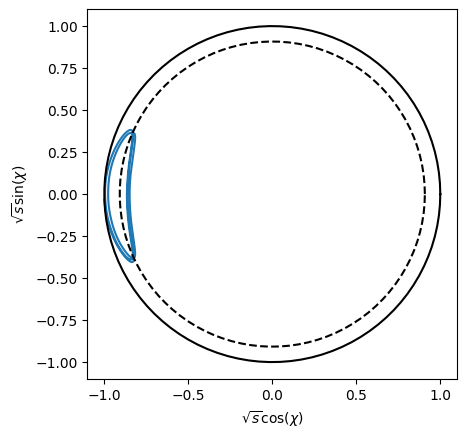

In [139]:
# Plot an example drift-convective banana particle trajectory
convective_indices = indices[np.where((banana_frac == 1) * (gammac_mean > 0.4))]
index = convective_indices[0]
res_ty = np.loadtxt(f"data/particle_{index}_traj.txt")

ax = plot_trajectory_poloidal(res_ty, helicity_M=1, helicity_N=0)

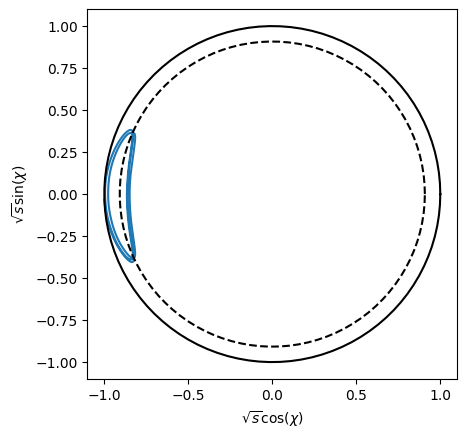

In [144]:
# Plot an example chaotic banana particle trajectory
chaotic_indices = indices[np.where((banana_frac == 1) * (Jpar_var > 0.1))]
index = chaotic_indices[0]
res_ty = np.loadtxt(f"data/particle_{index}_traj.txt")

ax = plot_trajectory_poloidal(res_ty, helicity_M=1, helicity_N=0)

(-1.1, 1.1)

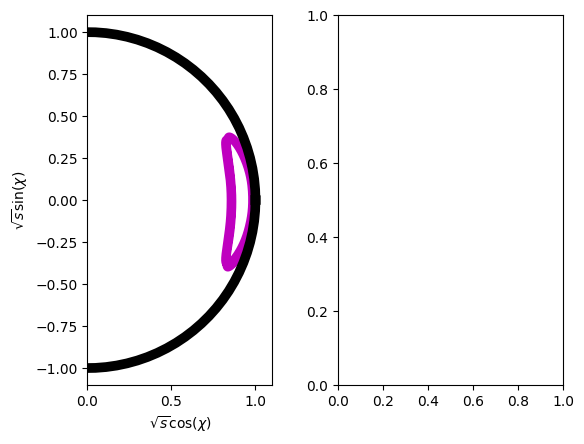

In [147]:
# Convective and Diffusive bananananana diagram

# Just take the one from the example on firm3d


# Convective
convective_indices = indices[np.where((banana_frac == 1) * (gammac_mean > 0.2))]
index = convective_indices[0]
res_ty = np.loadtxt(f"data/particle_{index}_traj.txt")
helicity_M=1
helicity_N=0
s = res_ty[:, 1]
theta = res_ty[:, 2]
zeta = res_ty[:, 3]
chi = helicity_M * theta - helicity_N * zeta
x = np.sqrt(s) * np.cos(chi)
y = np.sqrt(s) * np.sin(chi)

chi_grid = np.linspace(0, 2 * np.pi, 100)
s0 = s[0]
x0 = np.sqrt(s0) * np.cos(chi_grid)
y0 = np.sqrt(s0) * np.sin(chi_grid)

x1 = np.cos(chi_grid)
y1 = np.sin(chi_grid)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1,ncols=2)

ax[0].plot(-x, y,color='m',lw=5)
# ax[0].plot(x0, y0, color="black", linestyle="--")
ax[0].plot(x1, y1, color="black", linestyle="-",lw=7)
ax[0].set_xlabel(r"$\sqrt{s} \cos(\chi)$")
ax[0].set_ylabel(r"$\sqrt{s} \sin(\chi)$")
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlim(0, 1.1)
ax[0].set_ylim(-1.1, 1.1)

# Diffusive
# d_indices = indices[np.where((banana_frac == 1) * (Jpar_var > 0.1) * (nbounces>3))]
# index = d_indices[2]
# res_ty = np.loadtxt(f"data_og/particle_{index}_traj.txt")
# s = res_ty[:, 1]
# theta = res_ty[:, 2]
# zeta = res_ty[:, 3]
# chi = helicity_M * theta - helicity_N * zeta
# x = np.sqrt(s) * np.cos(chi)
# y = np.sqrt(s) * np.sin(chi)

# chi_grid = np.linspace(0, 2 * np.pi, 100)
# s0 = s[0]
# x0 = np.sqrt(s0) * np.cos(chi_grid)
# y0 = np.sqrt(s0) * np.sin(chi_grid)

# x1 = np.cos(chi_grid)
# y1 = np.sin(chi_grid)

# ax[1].plot(x, y,color='m',lw=1)
# # ax[0].plot(x0, y0, color="black", linestyle="--")
# ax[1].plot(x1, y1, color="black", linestyle="-",lw=7)
# ax[1].set_xlabel(r"$\sqrt{s} \cos(\chi)$")
# # ax[1].set_ylabel(r"$\sqrt{s} \sin(\chi)$")
# ax[1].set_aspect("equal", adjustable="box")
# ax[1].set_xlim(0, 1.1)
# ax[1].set_ylim(-1.1, 1.1)
# ax[1].set_yticks([])
# ax[0].set_xticks([-1.0,-0.5,0.0,0.5,1.0])

In [148]:
np.save('plotting/convective_x',x)
np.save('plotting/convective_y',y)

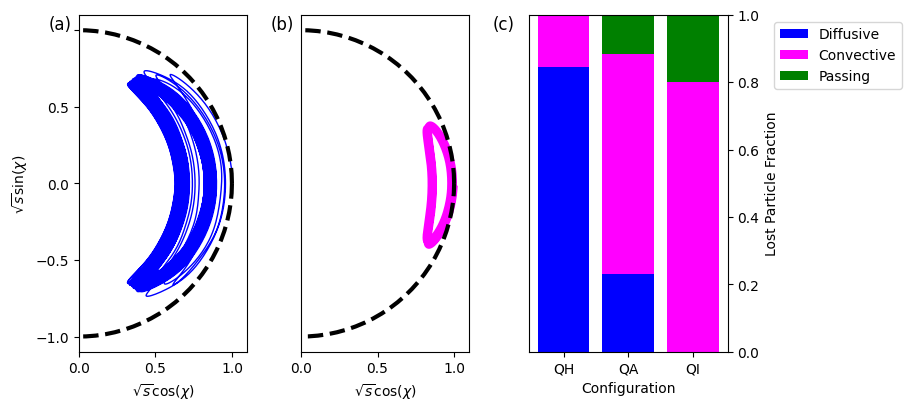

In [200]:
# Convective and Diffusive bananananana diagram

# Just take the one from the example on firm3d

import matplotlib.pyplot as plt
# Convective
chi_grid = np.linspace(0, 2 * np.pi, 100)
x1 = np.cos(chi_grid)
y1 = np.sin(chi_grid)

fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(9, 4),constrained_layout=True)
xd = np.load('plotting/diffusive_x.npy')
yd = np.load('plotting/diffusive_y.npy')
xc = np.load('plotting/convective_x.npy')
yc = np.load('plotting/convective_y.npy')

ax[1].plot(-xc, yc,color='magenta',lw=5)
# ax[0].plot(x0, y0, color="black", linestyle="--")
ax[1].plot(x1, y1, color="black", linestyle="--",lw=3)
ax[1].set_xlabel(r"$\sqrt{s} \cos(\chi)$")
ax[0].set_ylabel(r"$\sqrt{s} \sin(\chi)$")
ax[1].set_aspect("equal", adjustable="box")
ax[1].set_xlim(0.0, 1.1)
ax[1].set_ylim(-1.1, 1.1)

# Diffusive
chi_grid = np.linspace(0, 2 * np.pi, 100)
s0 = s[0]
x0 = np.sqrt(s0) * np.cos(chi_grid)
y0 = np.sqrt(s0) * np.sin(chi_grid)

x1 = np.cos(chi_grid)
y1 = np.sin(chi_grid)

ax[0].plot(xd, yd,color='blue',lw=1)
# ax[0].plot(x0, y0, color="black", linestyle="--")
ax[0].plot(x1, y1, color="black", linestyle="--",lw=3)
ax[0].set_xlabel(r"$\sqrt{s} \cos(\chi)$")
# ax[1].set_ylabel(r"$\sqrt{s} \sin(\chi)$")
ax[0].set_aspect("equal", adjustable="box")
ax[0].set_xlim(0, 1.1)
ax[0].set_ylim(-1.1, 1.1)
ax[1].set_yticks([])
ax[0].set_xticks([0.0,0.5,1.0])
ax[0].set_yticks([-1.0,-0.5,0.0,0.5,1.0])




# Stacked Bar Chart
categories = ['QH','QA','QI']
x = np.arange(len(categories))

#QH
subbounce_QH = np.load('plotting/subbounce_QH.npy')
num_trapped_QH = np.load('plotting/num_trapped_QH.npy')
num_passing_QH = np.load('plotting/num_passing_QH.npy')
num_trdb_QH = np.load('plotting/num_trdb_QH.npy')
num_trcb_QH = np.load('plotting/num_trcb_QH.npy')

nQH = num_trapped_QH+num_passing_QH
tr_db_QH = [num_trdb_QH/nQH] # Diffusive banana
tr_cb_QH = [num_trcb_QH/nQH] # Convective banana
sb_QH = [subbounce_QH/nQH]

ax[2].bar(x[0], tr_db_QH, label='Diffusive', color = 'blue')
ax[2].bar(x[0], tr_cb_QH,bottom=tr_db_QH, label='Convective', color = 'magenta')
ax[2].bar(x[0], sb_QH, bottom=np.array(tr_db_QH)+np.array(tr_cb_QH), label='Passing', color = 'green')
# plt.bar(x, group3, bottom=np.array(group1) + np.array(group2), label='Group 3')


#QA
subbounce_QA = np.load('plotting/subbounce_QA.npy')
num_trapped_QA = np.load('plotting/num_trapped_QA.npy')
num_passing_QA = np.load('plotting/num_passing_QA.npy')
num_trdb_QA = np.load('plotting/num_trdb_QA.npy')
num_trcb_QA = np.load('plotting/num_trcb_QA.npy')

nQA = num_trapped_QA+num_passing_QA
tr_db_QA = [num_trdb_QA/nQA] # Diffusive banana
tr_cb_QA = [num_trcb_QA/nQA] # Convective banana
sb_QA = [subbounce_QA/nQA]

ax[2].bar(x[1], tr_db_QA, color = 'blue')
ax[2].bar(x[1], tr_cb_QA,bottom=tr_db_QA, color = 'magenta')
ax[2].bar(x[1], sb_QA, bottom=np.array(tr_db_QA)+np.array(tr_cb_QA), color = 'green')
# plt.bar(x, group3, bottom=np.array(group1) + np.array(group2), label='Group 3')


#QI
subbounce_QI = np.load('plotting/subbounce_QI.npy')
num_trapped_QI = np.load('plotting/num_trapped_QI.npy')
num_passing_QI = np.load('plotting/num_passing_QI.npy')
num_trdb_QI = np.load('plotting/num_trdb_QI.npy')
num_trcb_QI = np.load('plotting/num_trcb_QI.npy')

nQI = num_trapped_QI+num_passing_QI
tr_db_QI = [num_trdb_QI/nQI] # Diffusive banana
tr_cb_QI = [num_trcb_QI/nQI] # Convective banana
sb_QI = [subbounce_QI/nQI]

ax[2].bar(x[2], tr_db_QI, color = 'blue')
ax[2].bar(x[2], tr_cb_QI,bottom=tr_db_QI, color = 'magenta')
ax[2].bar(x[2], sb_QI, bottom=np.array(tr_db_QI)+np.array(tr_cb_QI), color = 'green')
# plt.bar(x, group3, bottom=np.array(group1) + np.array(group2), label='Group 3')



ax[2].set_xticks(x, categories)
ax[2].set_xlabel('Configuration')
ax[2].set_ylabel('Lost Particle Fraction')
ax[2].set_ylim([0,1])
# plt.legend()
ax[2].legend(
    loc='upper left',            # Position of legend box
    bbox_to_anchor=(1.2, 1),    # (x, y) relative to axes
    # borderaxespad=0.
)
ax[2].yaxis.set_label_position("right")
ax[2].yaxis.tick_right()




# Add a b and c labels
labels = [item.get_text() for item in ax[0].get_yticklabels()]
labels[-1]=''
ax[0].set_yticklabels(labels)
labels = ['(a)', '(b)', '(c)']

for i, a in enumerate(ax):
    a.text(
        -0.18, 1, labels[i],
        transform=a.transAxes,  # use axes coordinates (0–1)
        fontsize=12,
        # fontweight='bold',
        va='top', ha='left'
    )